# Bayesian testing

In [1]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde
from scipy.stats import multivariate_normal


np.random.seed(0)

Data generating process / Data

$$x_i \sim N(1, 3)$$

## Testing: A rigorous link between deep ensembles and variational bayesian methods

The general framework in equation (4) of the paper is:

$$L(Q) := \int V(\theta) dQ(\theta) + \frac{\lambda_1}{2} \iint \kappa(\theta, \theta') dQ(\theta) dQ(\theta') + \lambda_2 \int \log q(\theta) q(\theta) d\theta$$
where 

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_1 \int (\nabla_1 \kappa)(\theta, \theta'), dQ(\theta') + \lambda_2 \nabla \log q(\theta)$$
And we will be working through From https://arxiv.org/pdf/2305.15027, section G1: toy exmaple: global minimiser

#### 1. Unregularised probabilistic lifting: deep ensembles
This is just the first term of the eqn



In [3]:

# 2D, 4 modes
mus = np.array([[3,3], [-3,3], [-3,-3], [3,-3]])

def loss(theta):  # theta shape (NE, 2)
    pdf = sum(0.25 * multivariate_normal.pdf(theta, mu, np.eye(2)) for mu in mus)
    return -np.log(pdf + 1e-300)

def grad_loss(theta):  # finite differences or analytical
    eps = 1e-5
    g = np.zeros_like(theta)
    for d in range(2):
        theta_p = theta.copy(); theta_p[:, d] += eps
        theta_m = theta.copy(); theta_m[:, d] -= eps
        g[:, d] = (loss(theta_p) - loss(theta_m)) / (2 * eps)
    return g

# Flat prior, so grad_V = grad_loss
grad_V = grad_loss

prior_dist = multivariate_normal(np.zeros(2), np.eye(2))
sample_prior = lambda size: prior_dist.rvs(size)

NE = 300
eta = 0.1
K = 10000
lambda_1 = 0.6   # λ_DRLE
lambda_2 = 0.2   # λ'_DRLE (the noise/KL term)

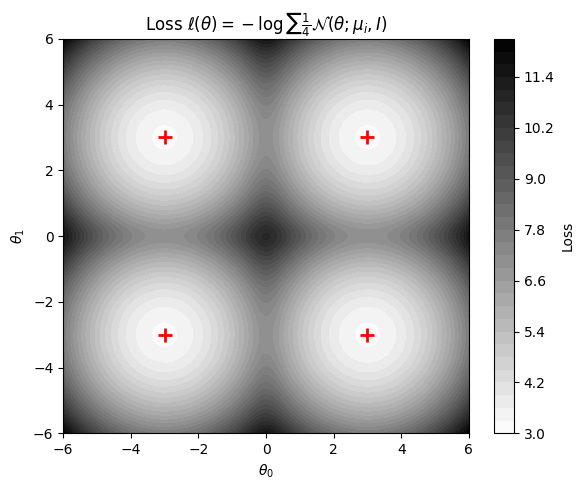

In [7]:
from matplotlib import cm

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
theta_grid_2d = np.stack([X.ravel(), Y.ravel()], axis=1)  # (40000, 2)
Z = loss_g2(theta_grid_2d).reshape(X.shape)

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, Z, levels=30, cmap='gray_r')
plt.colorbar(label='Loss')
for mu in mus:
    plt.plot(*mu, 'r+', ms=10, mew=2)
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title(r'Loss $\ell(\theta) = -\log \sum \frac{1}{4} \mathcal{N}(\theta; \mu_i, I)$')
plt.tight_layout()
plt.show()

Init the particles from the prior:
$$\theta_1 (0), \dots, \theta_n (0) \sim  Q_0\text{ , in this case the prior is $N(0,1)$ }$$

In [26]:
sample_prior = prior_dist.rvs
particles = sample_prior(size=NE)


$$L(Q) := \int V(\theta) dQ(\theta)$$
$$\nabla_W L[Q](\theta) = \nabla V(\theta) $$
with the particle updates following (for our case of $\lambda_1 = \lambda_2 = 0$):
$$d\theta_n(t) = - \nabla V (\theta_n(t)) dt$$
discretisiing
$$\theta_n^{(k+1)} = \theta_n^{(k)} - \eta \nabla V(\theta_n^{(k)})$$

In [17]:
for t in range(K):
    particles = particles - eta * grad_loss(particles) 

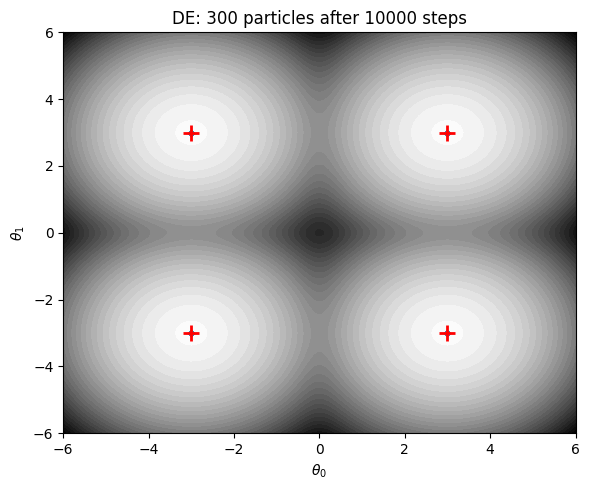

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
Z = loss(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

ax.contourf(X, Y, Z, levels=30, cmap='gray_r')
ax.scatter(particles[:, 0], particles[:, 1], s=8, c='steelblue', alpha=0.6)
for mu in mus:
    ax.plot(*mu, 'r+', ms=12, mew=2)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(f'DE: {NE} particles after {K} steps')
plt.tight_layout()
plt.show()

#### Regularisation with the Kullback-Leibler divergence: Deep Langevin ensembles
$$+ \lambda_2 \int \log q(\theta) q(\theta) d\theta$$
is the negative entropy of $Q$. Make entropy large -> spread particles out. \
In the partical update step

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_2 \nabla \log q(\theta)$$

such that
$$\theta_1(0), \dots, \theta_{N_E}(0) \sim Q_0 \quad d\theta_n(t) = -\nabla V(\theta_n(t))dt + \sqrt{2\lambda}dB_n(t), \quad n=1, \dots, N_E.$$

Note that: For some reason the entropy goes to brownian motion. note this is what lagevin mechainics is apparently

optimal based on posterior
$$q^*(\theta) \propto e^{-\frac{V(\theta)}{\lambda_2}} p (\theta)$$

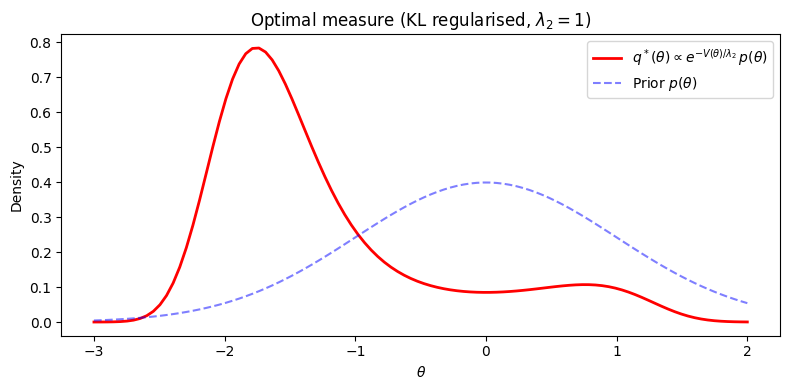

In [ ]:
# Optimal measure: q*(theta) ∝ exp(-V(theta)/lambda_2) * prior(theta)
lambda_2 = 1
optimal_vals = np.exp(-loss(grid) / lambda_2) * prior(grid)
optimal_vals /= np.trapz(optimal_vals, grid)  # normalise

plt.figure(figsize=(8, 4))
plt.plot(grid, optimal_vals, 'r-', lw=2, label=r'$q^*(\theta) \propto e^{-V(\theta)/\lambda_2}\, p(\theta)$')
plt.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label=r'Prior $p(\theta)$')
plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(f'Optimal measure (KL regularised, $\\lambda_2 = {lambda_2}$)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Langevin dynamics: dθ = -∇V(θ)dt + √(2λ₂)dB

particles_lang = sample_prior(size=NE)

for t in range(K):
    noise = np.random.randn(NE, 2) * np.sqrt(2 * lambda_2 * eta)
    particles_lang = particles_lang - eta * grad_V(particles_lang) + noise

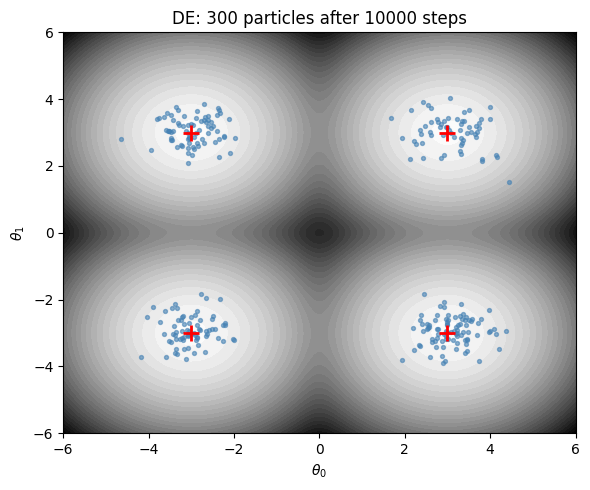

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
Z = loss(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

ax.contourf(X, Y, Z, levels=30, cmap='gray_r')
ax.scatter(particles_lang[:, 0], particles_lang[:, 1], s=8, c='steelblue', alpha=0.6)
for mu in mus:
    ax.plot(*mu, 'r+', ms=12, mew=2)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(f'DE: {NE} particles after {K} steps')
plt.tight_layout()
plt.show()

#### Deep repulsive Langevin ensembles
Now we add the repulsive kernel interaction term:
$$+ \frac{\lambda_1}{2} \iint \kappa(\theta, \theta') dQ(\theta) dQ(\theta')$$
Using a RBF kernel $\kappa(\theta, \theta') = \exp\!\left(-\frac{|\theta - \theta'|^2}{2h^2}\right)$, the full Wasserstein gradient is now

$$\nabla_W L[Q](\theta) = \nabla V(\theta) + \lambda_1 \int (\nabla_1 \kappa)(\theta, \theta') \, dQ(\theta') + \lambda_2 \nabla \log q(\theta)$$

The kernel term acts as a **repulsive force** between particles. particles that are close together push each other apart. This helps explore multiple modes without relying solely on noise.

The particle update becomes:
$$\theta_n^{(k+1)} = \theta_n^{(k)} - \eta \left[\nabla V(\theta_n^{(k)}) + \frac{\lambda_1}{N_E} \sum_{m=1}^{N_E} \nabla_1 \kappa(\theta_n^{(k)}, \theta_m^{(k)})\right] + \sqrt{2\lambda_2 \eta}\, \xi_n^{(k)}, \quad \xi_n^{(k)} \sim N(0,1)$$

where the kernel gradient for the RBF is:
$$\nabla_1 \kappa(\theta, \theta') = -\frac{\theta - \theta'}{h^2} \kappa(\theta, \theta')$$

In [24]:
from tqdm.notebook import tqdm
lambda_1 = 1.0

particles_drle = sample_prior(size=NE) # get particales 

# Get the sigma_k for the rbf as median of pairwise
pairwise_dists = np.abs(particles_drle[:, None] - particles_drle[None, :]) #NE * NE matrix
triu_dists = pairwise_dists[np.triu_indices(NE, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)

for t in tqdm(range(K)):

    ## repulsion
    diffs = particles_drle[:, None] - particles_drle[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    # Noise
    noise = np.random.randn(NE, 2) * np.sqrt(2 * lambda_2 * eta)

    # Update
    particles_drle = particles_drle - eta * (grad_V(particles_drle) + repulsion) + noise

  0%|          | 0/10000 [00:00<?, ?it/s]

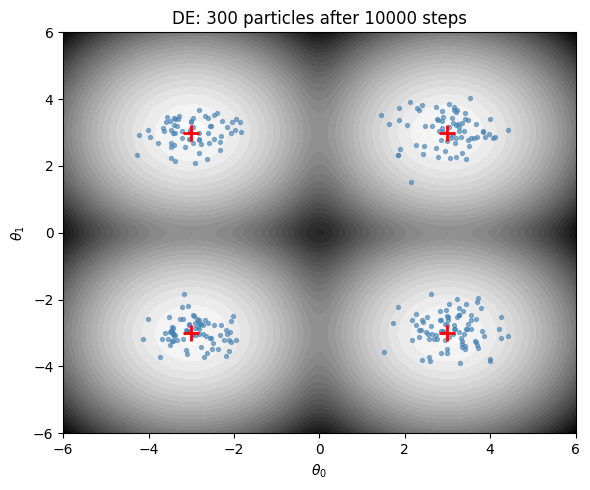

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

grid = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(grid, grid)
Z = loss(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

ax.contourf(X, Y, Z, levels=30, cmap='gray_r')
ax.scatter(particles_drle[:, 0], particles_lang[:, 1], s=8, c='steelblue', alpha=0.6)
for mu in mus:
    ax.plot(*mu, 'r+', ms=12, mew=2)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(f'DE: {NE} particles after {K} steps')
plt.tight_layout()
plt.show()

### SVGD Varient test
swapped out the update step where now the gradient is weighted by the average particle repulsion

In [ ]:
particles_drle_no_noise = sample_prior(size=NE) # get particales 
lambda_2 = 0
lambda_1 = 1

# Get the sigma_k for the rbf as median of pairwise
pairwise_dists = np.abs(particles_drle_no_noise[:, None] - particles_drle_no_noise[None, :]) #NE * NE matrix
triu_dists = pairwise_dists[np.triu_indices(NE, k=1)] # Take upper triangle (exclude diagonal zeros)
sigma_k = np.median(triu_dists)

for t in tqdm(range(K)):

    ## repulsion
    diffs = particles_drle_no_noise[:, None] - particles_drle_no_noise[None, :]  # (NE, NE)
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))              # (NE, NE)
    grad_K = -diffs / sigma_k**2 * K_mat                       # (NE, NE)
    repulsion = lambda_1 * grad_K.mean(axis=1)                  # (NE,)

    # Noise
    noise = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)

    # Update
    grad_vals = grad_V(particles_drle_no_noise)                    # (NE,)  — gradient at each particle
    weighted_grad = (K_mat * grad_vals[:, None]).mean(axis=0)  # (NE,)

    particles_drle_no_noise = particles_drle_no_noise - eta * (weighted_grad + repulsion) + noise

  0%|          | 0/100000 [00:00<?, ?it/s]

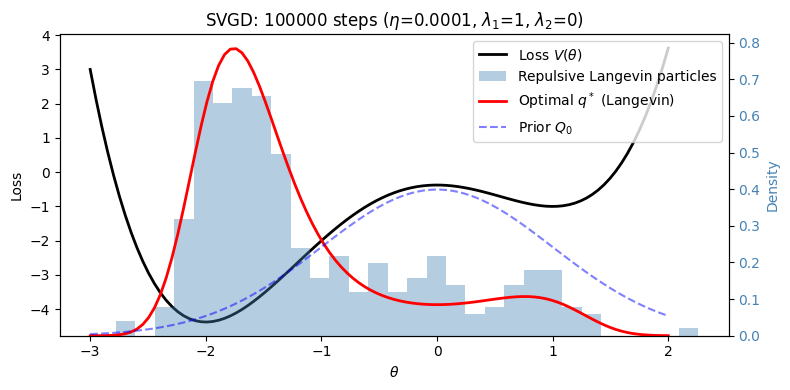

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Loss on left axis
ax1.plot(grid, loss_points, 'k-', lw=2, label='Loss $V(\\theta)$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Particle distribution on right axis
ax2 = ax1.twinx()
ax2.hist(particles_drle_no_noise, bins=30, density=True, alpha=0.4, color='steelblue', label='Repulsive Langevin particles')
ax2.plot(grid, optimal_vals, 'r-', lw=2, label=r'Optimal $q^*$ (Langevin)')
ax2.plot(grid, prior(grid), 'b--', lw=1.5, alpha=0.5, label='Prior $Q_0$')
ax2.set_ylabel('Density', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'SVGD: {K} steps ($\\eta$={eta}, $\\lambda_1$={lambda_1}, $\\lambda_2$={lambda_2})')
plt.tight_layout()
plt.show()

### Solving the DRLE stationary distribution (G.1)

The stationary $q^*$ for DRLE satisfies $u(\theta) = \log q^*(\theta)$ where:

$$u'(\theta) = -\frac{1}{\lambda_2}V'(\theta) - \frac{\lambda_1}{\lambda_2}\int (\nabla_1 \kappa)(\theta, \theta') \exp(u(\theta'))\, d\theta'$$

>  equation (136) in Appendix G.1
> which is exactly setting $\nabla_W L^{\text{fe}}[Q](\theta) = 0$ and rearranging for $u' = \nabla \log q^*$

 solve this via fixed-point iteration: guess $u$, compute the integral, integrate $u'$ to get a new $u$, normalise, repeat.


In [ ]:
sigma_k

0.9262501253885533

In [ ]:
def solve_drle_stationary(lambda_1, lambda_2, sigma_k=sigma_k, grid=np.linspace(-4, 3, 300), max_iter=50, tol=1e-8):
    dtheta = grid[1] - grid[0]
    grad_V = lambda theta: grad_loss(theta) + lambda_2 * theta

    # DLE closed form as starting guess
    V = lambda theta: loss(theta) - log_prior(theta)
    log_q_dle = -V(grid) / lambda_2
    log_q_dle -= np.log(trapezoid(np.exp(log_q_dle), grid))
    q_dle = np.exp(log_q_dle)

    # DRLE: iterative IDE solver
    u = log_q_dle.copy()
    for i in range(max_iter):
        exp_u = np.exp(u - u.max())
        grad_K = -(grid[:, None] - grid[None, :]) / sigma_k**2 \
                 * np.exp(-(grid[:, None] - grid[None, :])**2 / (2 * sigma_k**2))
        integral = trapezoid(grad_K * exp_u[None, :], grid, axis=1)
        u_prime = -(1/lambda_2) * grad_V(grid) - (lambda_1/lambda_2) * integral
        u_new = np.cumsum(u_prime) * dtheta
        u_new -= np.log(trapezoid(np.exp(u_new), grid))
        curr_score = np.max(np.abs(u_new - u))
        if curr_score < tol:
            print(f"Converged at iteration {i}")
            break
        u = u_new

    return np.exp(u), q_dle, grid, curr_score

q_drle, q_dle, theta_grid, score = solve_drle_stationary(lambda_1=1.0, lambda_2=1.0)

Converged at iteration 12


In [ ]:
np.linspace(1,3,21)

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
       2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ])

In [ ]:
lambda_range = np.linspace(0.1,2.5,25)
q_drles = []
for lambda_1 in lambda_range:
    q_drle, q_dle, theta_grid, score = solve_drle_stationary(lambda_1=lambda_1, lambda_2=1.0,max_iter=20000)
    # print(score)
    q_drles.append(q_drle)

Converged at iteration 4
Converged at iteration 5
Converged at iteration 6
Converged at iteration 7
Converged at iteration 8
Converged at iteration 8
Converged at iteration 9
Converged at iteration 10
Converged at iteration 11
Converged at iteration 12
Converged at iteration 13
Converged at iteration 15
Converged at iteration 17
Converged at iteration 19
Converged at iteration 21
Converged at iteration 23
Converged at iteration 26
Converged at iteration 29
Converged at iteration 34
Converged at iteration 39
Converged at iteration 46
Converged at iteration 57
Converged at iteration 86
Converged at iteration 144
Converged at iteration 239


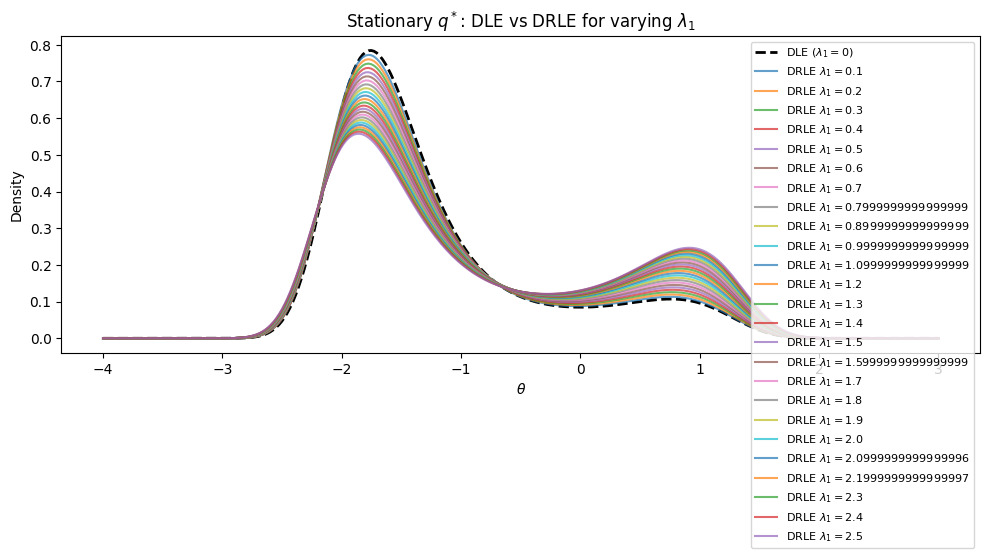

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(theta_grid, q_dle, 'k--', lw=2, label=r'DLE ($\lambda_1=0$)')
for lam1, drle in zip(lambda_range, q_drles):
    plt.plot(theta_grid, drle, lw=1.5, alpha=0.7, label=rf'DRLE $\lambda_1={lam1}$')

plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(r'Stationary $q^*$: DLE vs DRLE for varying $\lambda_1$')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

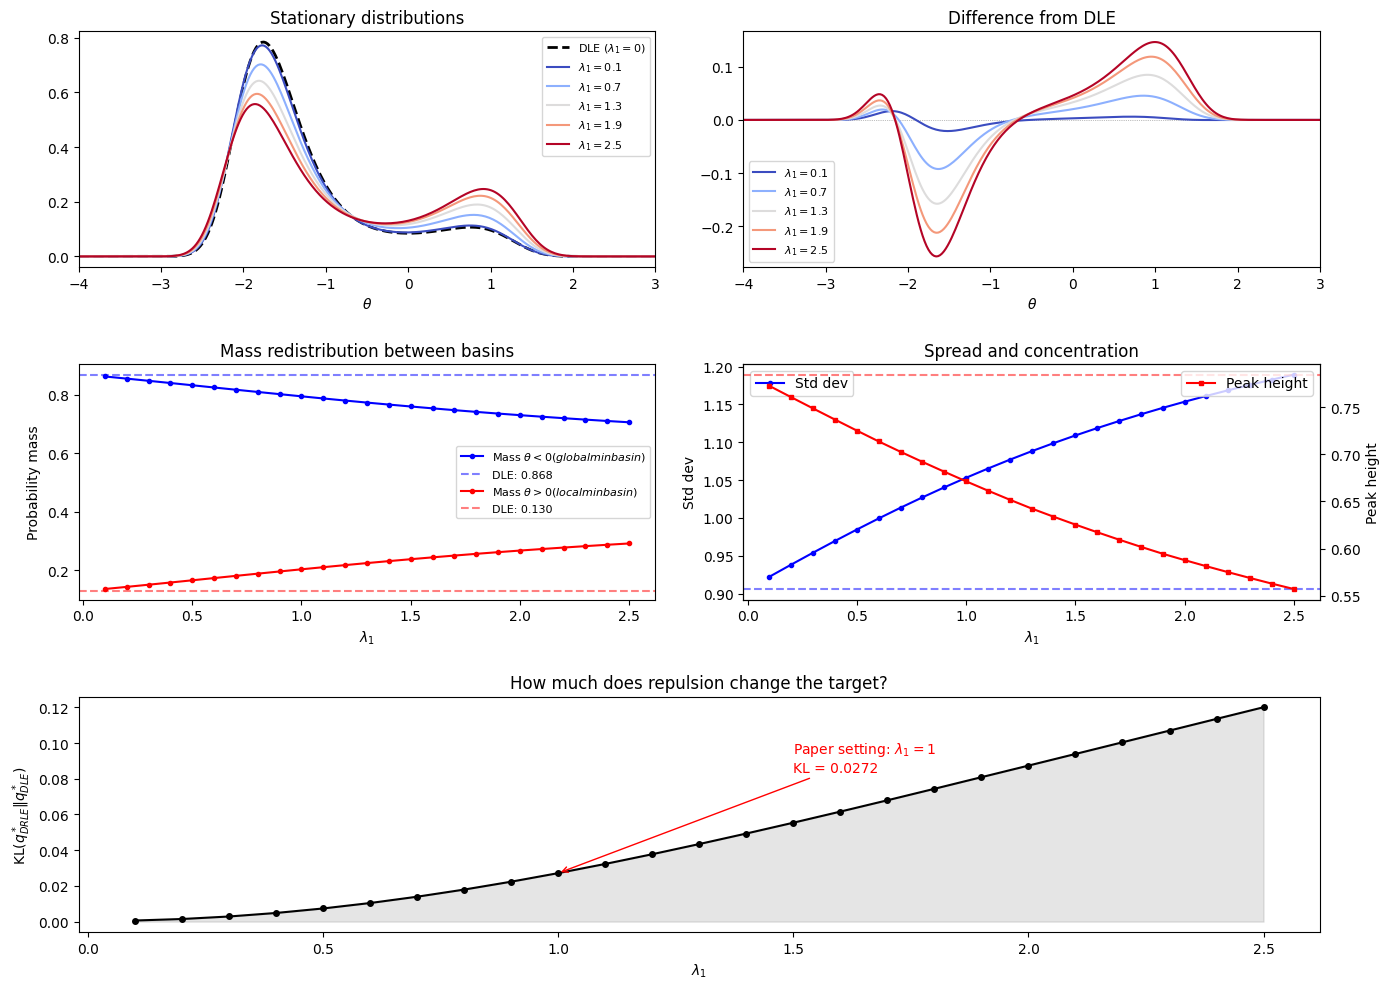

In [ ]:
# 1. Vectorise calculations (removes the massive loop entirely)
Q = np.array(q_drles)
tg, zi = theta_grid, np.argmin(np.abs(theta_grid))

# Process all parameters at once using axis=1
modes, peaks = tg[np.argmax(Q, axis=1)], np.max(Q, axis=1)
mass_L, mass_R = trapezoid(Q[:, :zi], tg[:zi], axis=1), trapezoid(Q[:, zi:], tg[zi:], axis=1)
means = trapezoid(tg * Q, tg, axis=1)
stds = np.sqrt(trapezoid((tg - means[:, None])**2 * Q, tg, axis=1))

mask = (Q > 1e-15) & (q_dle > 1e-15)
kls = trapezoid(np.where(mask, Q * np.log(Q / q_dle), 0), tg, axis=1)

# 2. DLE baseline (condensed to just what you need)
dle_p, dle_L, dle_R = np.max(q_dle), trapezoid(q_dle[:zi], tg[:zi]), trapezoid(q_dle[zi:], tg[zi:])
dle_std = np.sqrt(trapezoid((tg - trapezoid(tg * q_dle, tg))**2 * q_dle, tg))

# ============================================================
# Plot (optimised)
# ============================================================
fig = plt.figure(figsize=(14, 10))
ax1, ax2, ax3, ax4 = [plt.subplot(3, 2, i) for i in range(1, 5)]
ax5 = plt.subplot(3, 2, (5, 6)) # Natively spans the bottom row

# Top row: Select distributions & Differences (Combined loop)
ax1.plot(tg, q_dle, 'k--', lw=2, label='DLE ($\\lambda_1=0$)')
ax2.axhline(0, color='gray', lw=0.5, ls=':')
for i, c in zip([0, 6, 12, 18, 24], plt.cm.coolwarm(np.linspace(0, 1, 5))):
    lbl = f'$\\lambda_1={lambda_range[i]:.1f}$'
    ax1.plot(tg, Q[i], color=c, lw=1.5, label=lbl)
    ax2.plot(tg, Q[i] - q_dle, color=c, lw=1.5, label=lbl)
for ax, title in zip([ax1, ax2], ['Stationary distributions', 'Difference from DLE']):
    ax.set(xlabel=r'$\theta$', title=title, xlim=(-4, 3)); ax.legend(fontsize=8)

# Middle left: Mass redistribution
for y, dy, c, l in [(mass_L, dle_L, 'b', '< 0 (global min basin)'), (mass_R, dle_R, 'r', '> 0 (local min basin)')]:
    ax3.plot(lambda_range, y, f'{c}-o', ms=3, label=f'Mass $\\theta {l}$')
    ax3.axhline(dy, color=c, ls='--', alpha=0.5, label=f'DLE: {dy:.3f}')
ax3.set(xlabel=r'$\lambda_1$', ylabel='Probability mass', title='Mass redistribution between basins'); ax3.legend(fontsize=8)

# Middle right: Spread and concentration
ax4.plot(lambda_range, stds, 'b-o', ms=3, label='Std dev')
ax4.axhline(dle_std, color='b', ls='--', alpha=0.5)
ax4_2 = ax4.twinx()
ax4_2.plot(lambda_range, peaks, 'r-s', ms=3, label='Peak height')
ax4_2.axhline(dle_p, color='r', ls='--', alpha=0.5)
ax4.set(xlabel=r'$\lambda_1$', ylabel='Std dev', title='Spread and concentration'); ax4_2.set_ylabel('Peak height')
ax4.legend(loc='upper left'); ax4_2.legend(loc='upper right')

# Bottom: KL divergence
ax5.plot(lambda_range, kls, 'k-o', ms=4)
ax5.fill_between(lambda_range, 0, kls, alpha=0.1, color='k')
ax5.set(xlabel=r'$\lambda_1$', ylabel=r'KL$(q^*_{DRLE} \| q^*_{DLE})$', title='How much does repulsion change the target?')

pidx = np.argmin(np.abs(lambda_range - 1.0))
ax5.annotate(f'Paper setting: $\\lambda_1=1$\nKL = {kls[pidx]:.4f}', (lambda_range[pidx], kls[pidx]),
             xytext=(1.5, max(kls) * 0.7), arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.tight_layout(h_pad=2.0, w_pad=2.0)

## Convergence speeds

In [ ]:
# Pre-compute the true stationary distributions
lambda_1 = lambda_2 = 1

q_drle_true, q_dle_true, theta_grid, _ = solve_drle_stationary(lambda_1=lambda_1, lambda_2=lambda_2)

particles_lang = sample_prior(size=NE)
particles_drle = sample_prior(size=NE)

check_every = 200
kl_dle_hist = []
kl_drle_hist = []
steps = []

for t in tqdm(range(K)):
    # DLE update
    noise_l = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_lang = particles_lang - eta * grad_V(particles_lang) + noise_l

    # DRLE update
    diffs = particles_drle[:, None] - particles_drle[None, :]
    K_mat = np.exp(-diffs**2 / (2 * sigma_k**2))
    grad_K = -diffs / sigma_k**2 * K_mat
    repulsion = lambda_1 * grad_K.mean(axis=1)
    noise_r = np.random.randn(NE) * np.sqrt(2 * lambda_2 * eta)
    particles_drle = particles_drle - eta * (grad_V(particles_drle) + repulsion) + noise_r

    if (t + 1) % check_every == 0:
        # KDE of particles, evaluate on grid
        kde_dle = gaussian_kde(particles_lang)(theta_grid)
        kde_drle = gaussian_kde(particles_drle)(theta_grid)

        # KL(kde || true)
        mask_dle = (kde_dle > 1e-15) & (q_dle_true > 1e-15)
        kl_dle = trapezoid(np.where(mask_dle, kde_dle * np.log(kde_dle / q_dle_true), 0), theta_grid)

        mask_drle = (kde_drle > 1e-15) & (q_drle_true > 1e-15)
        kl_drle = trapezoid(np.where(mask_drle, kde_drle * np.log(kde_drle / q_drle_true), 0), theta_grid)

        kl_dle_hist.append(kl_dle)
        kl_drle_hist.append(kl_drle)
        steps.append(t + 1)

Converged at iteration 12


  0%|          | 0/100000 [00:00<?, ?it/s]

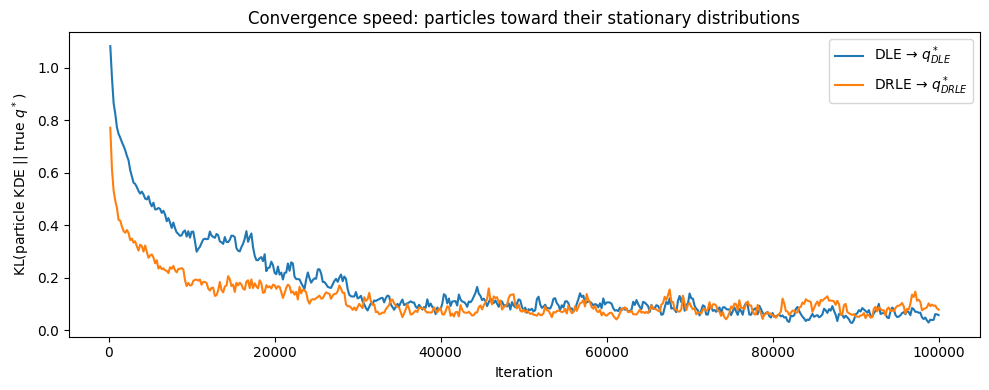

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(steps, kl_dle_hist, label='DLE → $q^*_{DLE}$')
plt.plot(steps, kl_drle_hist, label='DRLE → $q^*_{DRLE}$')
plt.xlabel('Iteration')
plt.ylabel('KL(particle KDE || true $q^*$)')
plt.title('Convergence speed: particles toward their stationary distributions')
plt.legend()
plt.tight_layout()
plt.show()

### Questions
1. I dont really understand how the negative entropy term becomes standard brownian motion
 1.1. How does this motion actually effect the distribution, e.g. does a fatter tailed normal brownian => differnt target distribtion? or is the direct brownian result nessesitate normal
2. rbf kernel thigns about the sigma computed at every step vs..